# 02. ROSE and LROM Cross Section Comparison

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import LogFormatterMathtext
import numpy as np
import pandas as pd

# Resolve imports whether execution starts from the repository or notebook directory.
ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "lrom_legacy").is_dir()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import benchmark_helper
import lrom_legacy.v2_0 as lrom

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})
LOG_FORMATTER = LogFormatterMathtext(base=10)

## 1. System Setup

In [2]:
# Physical system, shared design, and comparison grids.
TARGET = (40, 20)
PROJECTILE = (1, 0)
LAB_ENERGY = 14.1
L_MAX = 10
MESH_SIZE = 600
N_TRAIN = 200
N_TEST = 100
HALF_WIDTH = 0.20
ANGLES_DEG = np.arange(1.0, 180.0, 1.0)
BASIS_SIZES = (4, 6, 8, 10, 12)
ROSE_EIM_SIZES = (4, 6, 8, 10, 12)
LROM_PREDICTOR_COUNTS = (4, 6, 8, 10, 12)
CAT_CONFIGURATIONS = tuple(zip(BASIS_SIZES, BASIS_SIZES))
DEFAULT_BASIS_SIZE = 6
DEFAULT_OPERATOR_COUNT = DEFAULT_BASIS_SIZE
STUDY_CONFIGURATIONS = CAT_CONFIGURATIONS
POTENTIAL_ELL = 2
POTENTIAL_RADIUS_LIMITS_FM = (0.5, 12.0)
TIMING_REPEATS = 3
TIMING_INNER_LOOPS = 20
SEED = 1204
ERROR_DENOMINATOR_FLOOR = 1e-12
PLOTTING_FLOOR = 1e-6
LS_LABEL = "LS-projected cross section"
BLUE_PINK_CMAP = LinearSegmentedColormap.from_list(
    "blue_to_pink", ("#1f4aa8", "#6f78d1", "#c468c5", "#f05a9d")
)


def median_pointwise_absolute_error(prediction, reference):
    return np.median(np.abs(np.asarray(prediction) - np.asarray(reference)), axis=1)

## 2. Training and Testing Samples

In [3]:
# The parked-v2 emulator supplies one shared high-fidelity design to every method.
emulator = lrom.LROM(
    target=TARGET,
    projectile=PROJECTILE,
    lab_energy=LAB_ENERGY,
    l=tuple(range(L_MAX + 1)),
    potential="full_woods-saxon",
)

central = dict(emulator.central_parameters)
ranges = {
    name: tuple(
        sorted(((1.0 - HALF_WIDTH) * value, (1.0 + HALF_WIDTH) * value))
    )
    for name, value in central.items()
}

# All radii returned by sampling are physical fm; no scaled coordinate is plotted.
emulator.sampling(
    training_ranges=ranges,
    testing_ranges=ranges,
    training_size=N_TRAIN,
    testing_size=N_TEST,
    mesh_size=MESH_SIZE,
    strategy="latin_hypercube",
    seed=SEED,
    high_fidelity_solver="runge_kutta",
    solver_options={"rk_tols": (1e-9, 1e-9)},
)

In [4]:
# Preserve ordered arrays for solvers and named dictionaries for public prediction calls.
design = emulator.samples.design
parameter_names = emulator.parameter_names
train_rows = design.training.values.copy()
test_rows = design.testing.values.copy()
train_ids = design.training.case_ids
test_ids = design.testing.case_ids

train_cases = [
    {name: float(value) for name, value in zip(parameter_names, row)}
    for row in train_rows
]
test_cases = [
    {name: float(value) for name, value in zip(parameter_names, row)}
    for row in test_rows
]

assert train_rows.shape == (N_TRAIN, len(parameter_names))
assert test_rows.shape == (N_TEST, len(parameter_names))
assert not any(np.array_equal(a, b) for a in train_rows for b in test_rows)

## 3. Potential and LROM Operator Locations

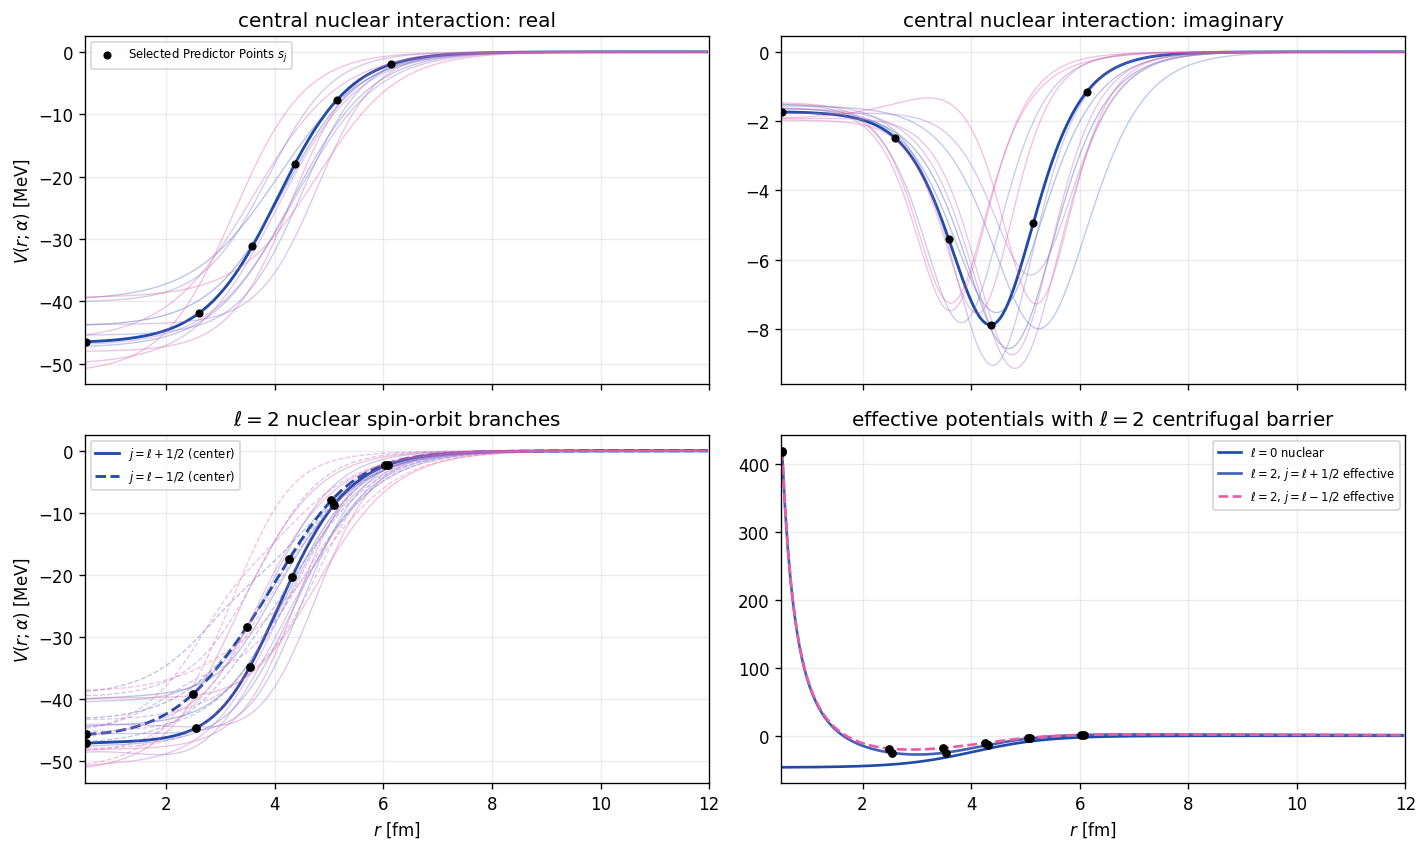

In [5]:
mesh = emulator.samples.mesh
radius_mesh = mesh.radius
plot_mask = (
    (radius_mesh >= POTENTIAL_RADIUS_LIMITS_FM[0])
    & (radius_mesh <= POTENTIAL_RADIUS_LIMITS_FM[1])
)
plot_radius = radius_mesh[plot_mask]
center_vector = np.array([central[name] for name in parameter_names])

# These are the exact operator locations expected from the default LROM fit.
displayed_predictors = lrom.build_effective_interaction_predictors(
    full_order_models=emulator.samples.full_order_models,
    rho=mesh.rho,
    radius=radius_mesh,
    central_values=center_vector,
    training_values=train_rows,
    testing_values=test_rows,
    predictor_count=DEFAULT_OPERATOR_COUNT,
    minimum_radius=0.5,
)

# Use the center plus a normalized spread of held-out potentials for context.
range_scale = np.array([ranges[name][1] - ranges[name][0] for name in parameter_names])
distance = np.linalg.norm((test_rows - center_vector) / range_scale, axis=1)
ranked = np.argsort(distance)
potential_rows = np.vstack(
    [center_vector, test_rows[ranked[np.linspace(0, len(ranked) - 1, 12, dtype=int)]]]
)
potential_norm = plt.Normalize(0, len(potential_rows) - 1)

fig, axes = plt.subplots(2, 2, figsize=(12.0, 7.2), sharex=True)
for row_index, row in enumerate(potential_rows):
    central_potential = lrom.full_woods_saxon(radius_mesh, row)
    spin_orbit_form = lrom.full_woods_saxon_spin_orbit(radius_mesh, row)
    barrier = benchmark_helper.centrifugal_barrier_mev(
        radius_mesh,
        ell=POTENTIAL_ELL,
        reduced_mass_mev=emulator.kinematics.mu,
    )
    nuclear_plus = central_potential + POTENTIAL_ELL * spin_orbit_form
    nuclear_minus = central_potential - (POTENTIAL_ELL + 1) * spin_orbit_form
    sample_color = BLUE_PINK_CMAP(potential_norm(row_index))
    style = {
        "color": sample_color,
        "alpha": 1.0 if row_index == 0 else 0.38,
        "lw": 1.7 if row_index == 0 else 0.8,
    }
    label_suffix = " (center)" if row_index == 0 else None

    axes[0, 0].plot(plot_radius, central_potential.real[plot_mask], **style)
    axes[0, 1].plot(plot_radius, central_potential.imag[plot_mask], **style)
    axes[1, 0].plot(
        plot_radius,
        nuclear_plus.real[plot_mask],
        **style,
        label=r"$j=\ell+1/2$" + label_suffix if label_suffix else None,
    )
    axes[1, 0].plot(
        plot_radius,
        nuclear_minus.real[plot_mask],
        linestyle="--",
        **style,
        label=r"$j=\ell-1/2$" + label_suffix if label_suffix else None,
    )
    if row_index == 0:
        axes[1, 1].plot(
            plot_radius,
            central_potential.real[plot_mask],
            color=BLUE_PINK_CMAP(0.0),
            lw=1.6,
            label=r"$\ell=0$ nuclear",
        )
        axes[1, 1].plot(
            plot_radius,
            (nuclear_plus.real + barrier)[plot_mask],
            color=BLUE_PINK_CMAP(0.15),
            lw=1.6,
            label=r"$\ell=2$, $j=\ell+1/2$ effective",
        )
        axes[1, 1].plot(
            plot_radius,
            (nuclear_minus.real + barrier)[plot_mask],
            color=BLUE_PINK_CMAP(0.95),
            linestyle="--",
            lw=1.6,
            label=r"$\ell=2$, $j=\ell-1/2$ effective",
        )

# Mark selected LROM predictor points in black on the central curves.
central_potential = lrom.full_woods_saxon(radius_mesh, center_vector)
spin_orbit_form = lrom.full_woods_saxon_spin_orbit(radius_mesh, center_vector)
barrier = benchmark_helper.centrifugal_barrier_mev(
    radius_mesh, ell=POTENTIAL_ELL, reduced_mass_mev=emulator.kinematics.mu
)
nuclear_branches = {
    (POTENTIAL_ELL, 0): central_potential + POTENTIAL_ELL * spin_orbit_form,
    (POTENTIAL_ELL, 1): central_potential - (POTENTIAL_ELL + 1) * spin_orbit_form,
}
central_radii = displayed_predictors[0].selected_radii
axes[0, 0].scatter(
    central_radii, np.interp(central_radii, radius_mesh, central_potential.real),
    color="black", s=15, zorder=5, label=r"Selected Predictor Points $s_j$",
)
axes[0, 1].scatter(
    central_radii, np.interp(central_radii, radius_mesh, central_potential.imag),
    color="black", s=15, zorder=5,
)
for channel, branch in nuclear_branches.items():
    radii = displayed_predictors[channel].selected_radii
    axes[1, 0].scatter(
        radii, np.interp(radii, radius_mesh, branch.real),
        color="black", s=18, zorder=5,
    )
    axes[1, 1].scatter(
        radii, np.interp(radii, radius_mesh, branch.real + barrier),
        color="black", s=18, zorder=5,
    )

for ax, title in zip(
    axes.flat,
    (
        "central nuclear interaction: real",
        "central nuclear interaction: imaginary",
        r"$\ell=2$ nuclear spin-orbit branches",
        r"effective potentials with $\ell=2$ centrifugal barrier",
    ),
):
    ax.set_title(title)
    ax.set_xlim(*POTENTIAL_RADIUS_LIMITS_FM)
for ax in axes[1]:
    ax.set_xlabel(r"$r$ [fm]")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$V(r;\alpha)$ [MeV]")
axes[0, 0].legend(fontsize=7)
axes[1, 0].legend(fontsize=7)
axes[1, 1].legend(fontsize=7)
fig.tight_layout()

assert all(np.all(state.selected_radii >= 0.5) for state in displayed_predictors.values())
plt.show()

## 4. ROSE Pipeline

In [6]:
# This is the only high-level ROSE construction/evaluation call in the notebook.
rose_pipeline = benchmark_helper.RoseCrossSectionPipeline(
    emulator=emulator,
    training_rows=train_rows,
    testing_rows=test_rows,
    angles_degrees=ANGLES_DEG,
    denominator_floor=ERROR_DENOMINATOR_FLOOR,
    timing_repeats=TIMING_REPEATS,
    timing_inner_loops=TIMING_INNER_LOOPS,
)
rose_comparison = rose_pipeline.run(
    basis_sizes=BASIS_SIZES,
    eim_sizes=ROSE_EIM_SIZES,
    configurations=STUDY_CONFIGURATIONS,
)

rose_emulators = rose_comparison.emulators
reference_sae = rose_emulators[(BASIS_SIZES[0], ROSE_EIM_SIZES[0])]
fom_train_xs = rose_comparison.fom_training_cross_sections
fom_test_xs = rose_comparison.fom_testing_cross_sections
rose_results = rose_comparison.results
default_key = (DEFAULT_BASIS_SIZE, DEFAULT_OPERATOR_COUNT)

rose_channel_counts = benchmark_helper.validate_partial_wave_topology(
    reference_sae.rbes,
    l_max=L_MAX,
)
assert set(rose_results) == set(STUDY_CONFIGURATIONS)
assert rose_channel_counts == (1,) + (2,) * L_MAX
assert fom_train_xs.shape == (N_TRAIN, ANGLES_DEG.size)
assert fom_test_xs.shape == (N_TEST, ANGLES_DEG.size)

## 5. LROM and Least-Squares Pipelines

In [7]:
# LROM training is deliberately outside the ROSE pipeline and owns its timings.
lrom_study = benchmark_helper.LromCrossSectionStudy(
    emulator=emulator,
    training_cases=train_cases,
    testing_cases=test_cases,
    training_rows=train_rows,
    testing_rows=test_rows,
    fom_training_cross_sections=fom_train_xs,
    fom_testing_cross_sections=fom_test_xs,
    angles_degrees=ANGLES_DEG,
    denominator_floor=ERROR_DENOMINATOR_FLOOR,
    timing_repeats=TIMING_REPEATS,
    timing_inner_loops=TIMING_INNER_LOOPS,
)

old_v2_comparison = lrom_study.run_parked_v2_reference(
    basis_size=DEFAULT_BASIS_SIZE,
    operator_count=DEFAULT_OPERATOR_COUNT,
)
lrom_comparison = lrom_study.run_lrom(
    basis_sizes=BASIS_SIZES,
    operator_counts=LROM_PREDICTOR_COUNTS,
    capture_predictors_at=default_key,
    configurations=STUDY_CONFIGURATIONS,
)
ls_comparison = lrom_study.run_ls(
    basis_sizes=BASIS_SIZES,
    operator_count=LROM_PREDICTOR_COUNTS[0],
)

old_v2_results = old_v2_comparison.results
lrom_results = lrom_comparison.results
archive_lrom_results = lrom_results
default_predictors = lrom_comparison.predictors
ls_results = ls_comparison.results

assert set(lrom_results) == set(STUDY_CONFIGURATIONS)
validated_predictor_radii = benchmark_helper.validate_predictor_radii(
    displayed_predictors,
    default_predictors,
)
for result in (*rose_results.values(), *lrom_results.values()):
    assert result["train_xs"].shape == (N_TRAIN, ANGLES_DEG.size)
    assert result["test_xs"].shape == (N_TEST, ANGLES_DEG.size)
for result in ls_results.values():
    assert result["train_xs"].shape == (N_TRAIN, ANGLES_DEG.size)
    assert result["test_xs"].shape == (N_TEST, ANGLES_DEG.size)

# Performance is a regenerated diagnostic, not a scientific invariant.
default_lrom_median_error = float(
    np.median(lrom_results[default_key]["test_median_over_angle_error"])
)
default_old_v2_median_error = float(
    np.median(old_v2_results[default_key]["test_median_over_angle_error"])
)
performance_diagnostic = {
    "LROM default median pointwise error": default_lrom_median_error,
    "parked-v2 default median pointwise error": default_old_v2_median_error,
    "LROM minus parked-v2": default_lrom_median_error - default_old_v2_median_error,
}
performance_diagnostic

{'LROM default median pointwise error': 0.014547165554457717,
 'parked-v2 default median pointwise error': 0.11937176718385317,
 'LROM minus parked-v2': -0.10482460162939546}

## 6. Representative Cross Sections

,Vv,Wv,Wd,Vso,Rv,Rd,Rso,av,ad,aso
case,,,,,,,,,,
A,54.763,1.865,6.350,6.819,3.822,4.775,3.344,0.732,0.611,0.676
B,48.055,1.971,6.441,5.537,4.297,4.162,4.086,0.571,0.432,0.505
C,55.378,1.946,6.573,7.258,4.039,5.033,2.860,0.646,0.536,0.572


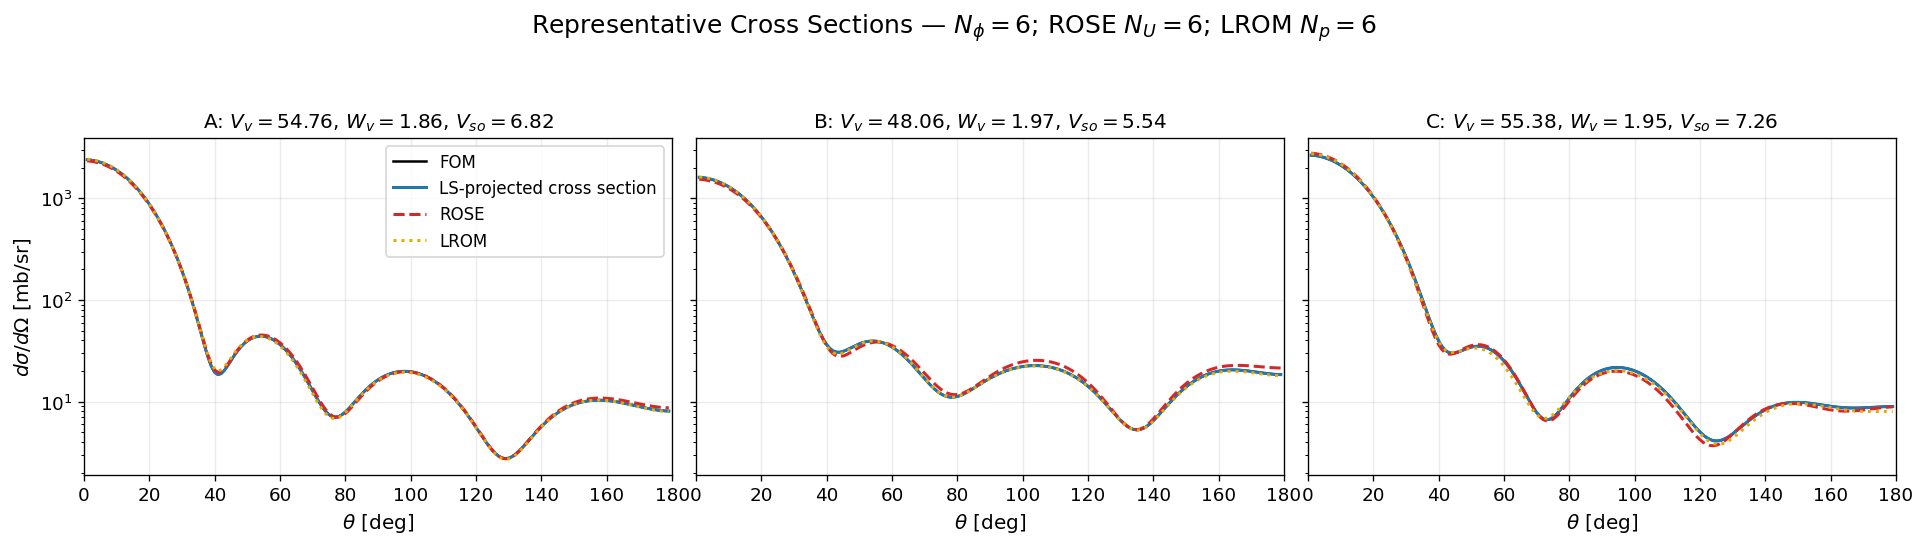

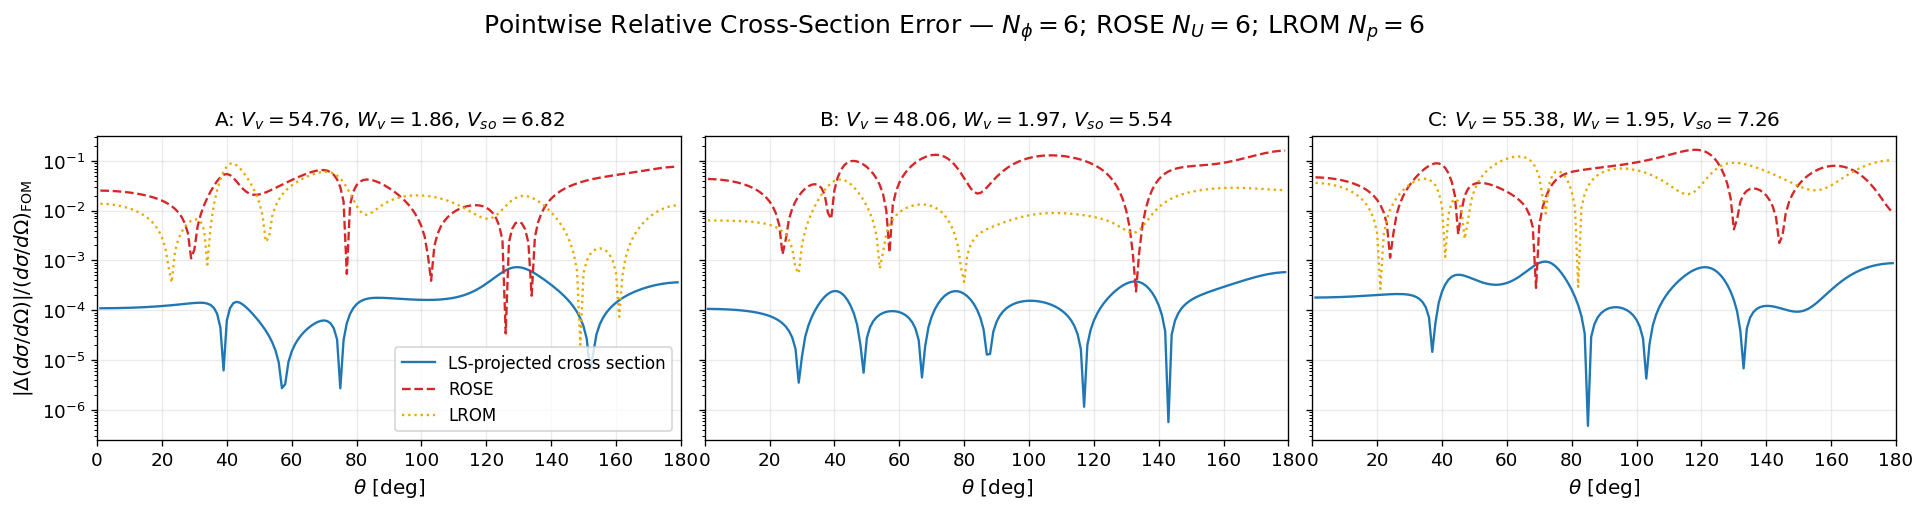

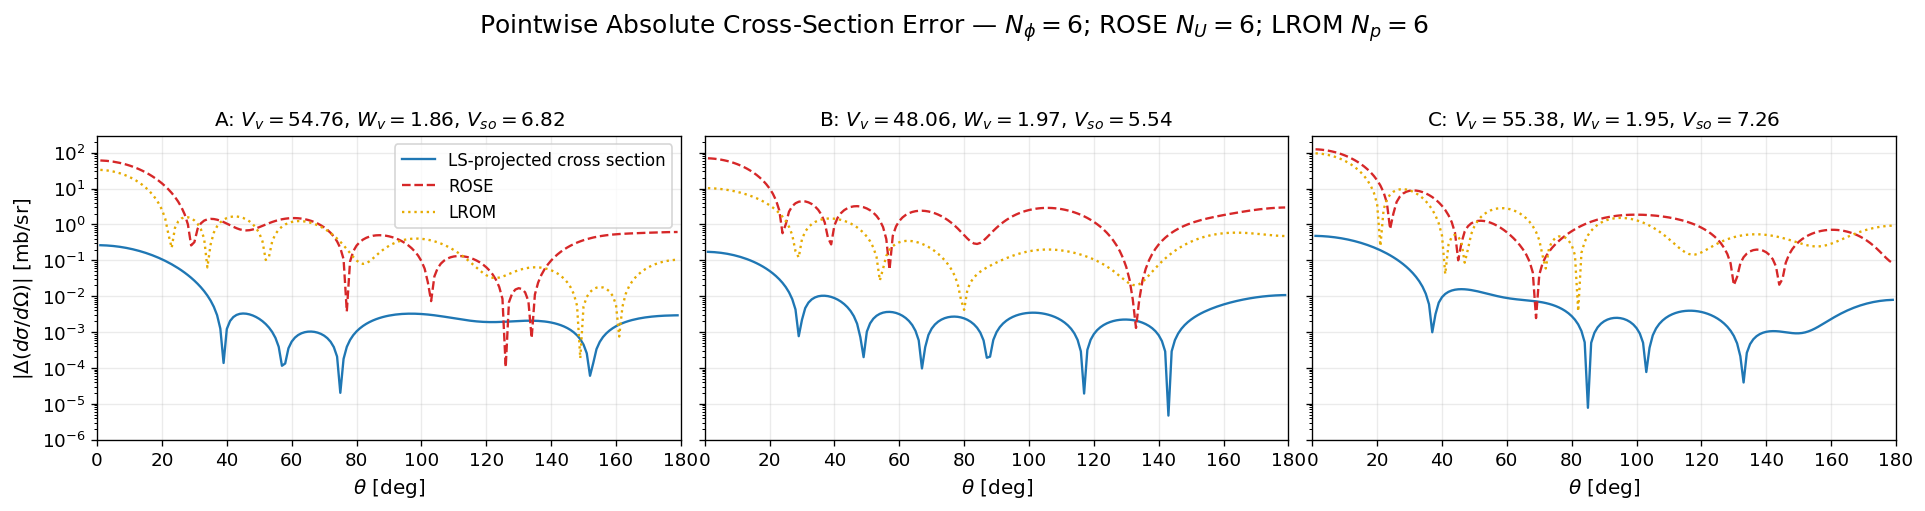

In [8]:
# Select three cases spanning the joint ROSE/LROM error ranking.
lrom_rank = np.argsort(np.argsort(lrom_results[default_key]["test_median_over_angle_error"]))
rose_rank = np.argsort(np.argsort(rose_results[default_key]["test_median_over_angle_error"]))
ordered = np.argsort(lrom_rank + rose_rank)
selected_indices = [int(i) for i in ordered[np.linspace(0, len(ordered) - 1, 5, dtype=int)[1:-1]]]

CASE_LABELS = ("A", "B", "C")
parameter_selection_table = pd.DataFrame(
    test_rows[selected_indices], columns=parameter_names, index=CASE_LABELS
).rename_axis("case")
display(parameter_selection_table.round(3))

representative_methods = (
    (ls_results[DEFAULT_BASIS_SIZE]["test_xs"], LS_LABEL, "tab:blue", "-"),
    (rose_results[default_key]["test_xs"], "ROSE", "tab:red", "--"),
    (lrom_results[default_key]["test_xs"], "LROM", "#E6AB02", ":"),
)
CASE_TITLE_SIZE = 12
AXIS_LABEL_SIZE = 12
TICK_LABEL_SIZE = 11
LEGEND_FONT_SIZE = 10
FIGURE_TITLE_SIZE = 15
configuration_title = (
    rf"$N_\phi={DEFAULT_BASIS_SIZE}$; ROSE $N_U={DEFAULT_OPERATOR_COUNT}$; "
    rf"LROM $N_p={DEFAULT_OPERATOR_COUNT}$"
)
case_titles = []
for case_label, index in zip(CASE_LABELS, selected_indices):
    row = test_rows[index]
    case_titles.append(
        rf"{case_label}: $V_v={row[parameter_names.index('Vv')]:.2f}$, "
        rf"$W_v={row[parameter_names.index('Wv')]:.2f}$, "
        rf"$V_{{so}}={row[parameter_names.index('Vso')]:.2f}$"
    )

fig, axes = plt.subplots(1, len(selected_indices), figsize=(16.0, 4.6), sharex=True, sharey=True)
for ax, index, case_title in zip(axes, selected_indices, case_titles):
    ax.plot(ANGLES_DEG, fom_test_xs[index], color="black", label="FOM")
    for values, method, color, style in representative_methods:
        ax.plot(ANGLES_DEG, values[index], style, color=color, lw=1.8, label=method)
    ax.set_title(case_title, fontsize=CASE_TITLE_SIZE)
    ax.set_xlabel(r"$\theta$ [deg]", fontsize=AXIS_LABEL_SIZE)
    ax.tick_params(axis="both", labelsize=TICK_LABEL_SIZE)
    ax.set_yscale("log", nonpositive="clip")
    ax.yaxis.set_major_formatter(LOG_FORMATTER)
    ax.set_xlim(0.0, 180.0)
axes[0].set_ylabel(r"$d\sigma/d\Omega$ [mb/sr]", fontsize=AXIS_LABEL_SIZE)
axes[0].legend(fontsize=LEGEND_FONT_SIZE)
fig.suptitle("Representative Cross Sections" + " — " + configuration_title, fontsize=FIGURE_TITLE_SIZE)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.92))
plt.show()

fig, axes = plt.subplots(1, len(selected_indices), figsize=(16.0, 4.3), sharex=True, sharey=True)
for ax, index, case_title in zip(axes, selected_indices, case_titles):
    for values, method, color, style in representative_methods:
        ax.plot(
            ANGLES_DEG,
            benchmark_helper.pointwise_relative_error(
                values[index], fom_test_xs[index], ERROR_DENOMINATOR_FLOOR
            ),
            style, color=color, lw=1.4, label=method,
        )
    ax.set_title(case_title, fontsize=CASE_TITLE_SIZE)
    ax.set_xlabel(r"$\theta$ [deg]", fontsize=AXIS_LABEL_SIZE)
    ax.tick_params(axis="both", labelsize=TICK_LABEL_SIZE)
    ax.set_yscale("log", nonpositive="clip")
    ax.yaxis.set_major_formatter(LOG_FORMATTER)
    ax.set_xlim(0.0, 180.0)
axes[0].set_ylabel(r"$|\Delta(d\sigma/d\Omega)|/(d\sigma/d\Omega)_{\mathrm{FOM}}$", fontsize=AXIS_LABEL_SIZE)
axes[0].legend(fontsize=LEGEND_FONT_SIZE)
fig.suptitle("Pointwise Relative Cross-Section Error" + " — " + configuration_title, fontsize=FIGURE_TITLE_SIZE)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.92))
plt.show()

fig, axes = plt.subplots(1, len(selected_indices), figsize=(16.0, 4.3), sharex=True, sharey=True)
for ax, index, case_title in zip(axes, selected_indices, case_titles):
    for values, method, color, style in representative_methods:
        ax.plot(
            ANGLES_DEG,
            np.maximum(np.abs(values[index] - fom_test_xs[index]), PLOTTING_FLOOR),
            style, color=color, lw=1.4, label=method,
        )
    ax.set_title(case_title, fontsize=CASE_TITLE_SIZE)
    ax.set_xlabel(r"$\theta$ [deg]", fontsize=AXIS_LABEL_SIZE)
    ax.tick_params(axis="both", labelsize=TICK_LABEL_SIZE)
    ax.set_yscale("log", nonpositive="clip")
    ax.yaxis.set_major_formatter(LOG_FORMATTER)
    ax.set_xlim(0.0, 180.0)
axes[0].set_ylim(bottom=1e-6)
axes[0].set_ylabel(r"$|\Delta(d\sigma/d\Omega)|$ [mb/sr]", fontsize=AXIS_LABEL_SIZE)
axes[0].legend(fontsize=LEGEND_FONT_SIZE)
fig.suptitle("Pointwise Absolute Cross-Section Error" + " — " + configuration_title, fontsize=FIGURE_TITLE_SIZE)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.92))
plt.show()

## 7. Cross-Section Error

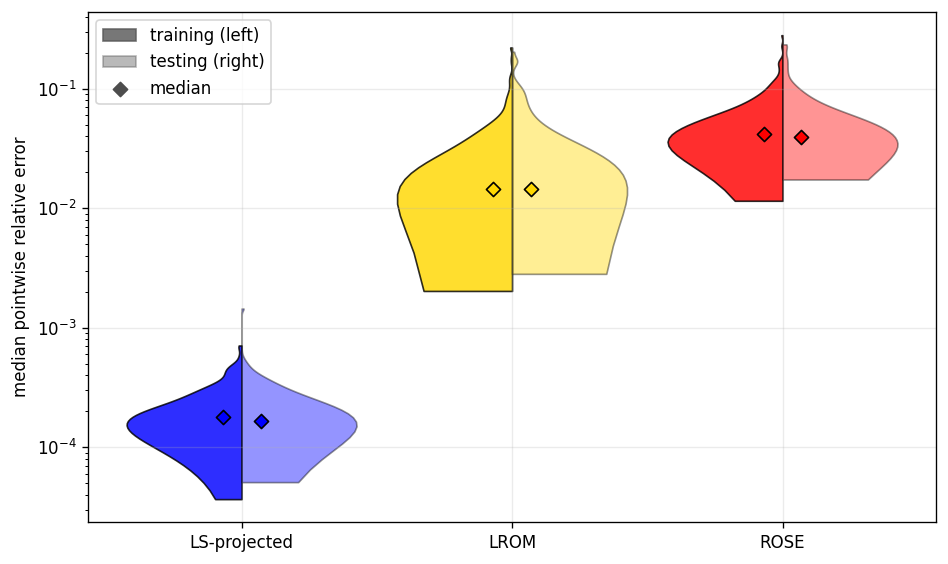

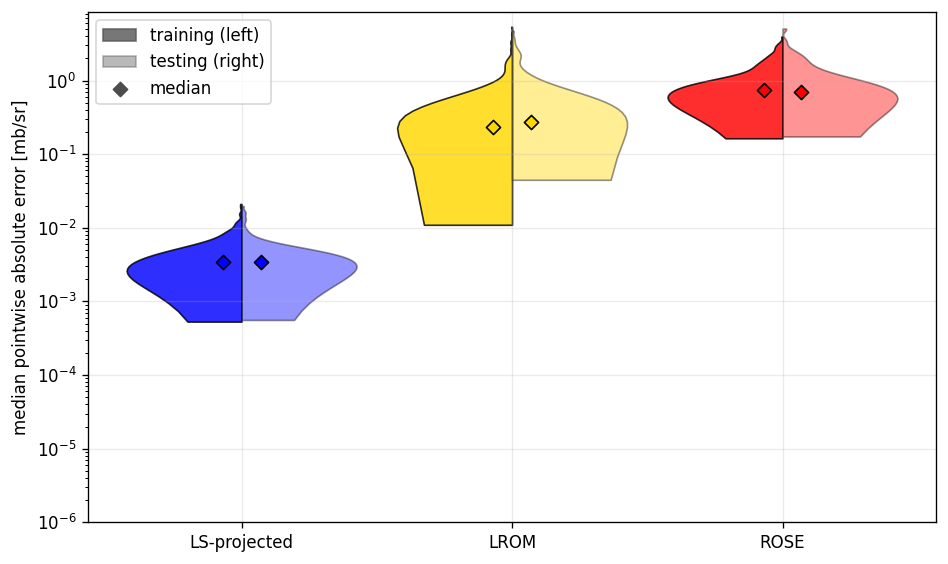

In [9]:
METHOD_VIOLIN_COLORS = {"LS-projected": "blue", "LROM": "gold", "ROSE": "red"}
categories = (
    ("LS-projected", ls_results[DEFAULT_BASIS_SIZE]),
    ("LROM", lrom_results[default_key]),
    ("ROSE", rose_results[default_key]),
)
category_positions = np.arange(1, len(categories) + 1)
fig, ax = plt.subplots(figsize=(8.0, 4.8))

# Half violins retain raw dimensionless errors; only the display axis is logarithmic.
for center_position, (method, result) in zip(category_positions, categories):
    method_color = METHOD_VIOLIN_COLORS[method]
    for side, key, opacity in (
        (-1, "train_median_over_angle_error", 0.82),
        (+1, "test_median_over_angle_error", 0.42),
    ):
        values = result[key]
        parts = ax.violinplot(
            [values],
            positions=[center_position],
            widths=0.85,
            showextrema=False,
        )
        body = parts["bodies"][0]
        vertices = body.get_paths()[0].vertices
        vertices[:, 0] = (
            np.minimum(vertices[:, 0], center_position)
            if side < 0
            else np.maximum(vertices[:, 0], center_position)
        )
        body.set_facecolor(method_color)
        body.set_edgecolor("black")
        body.set_alpha(opacity)
        ax.scatter(
            center_position + 0.07 * side,
            np.median(values),
            marker="D",
            color=method_color,
            edgecolor="black",
            zorder=6,
        )

ax.set_yscale("log", nonpositive="clip")
ax.yaxis.set_major_formatter(LOG_FORMATTER)
ax.set_xticks(category_positions, [label for label, _ in categories])
ax.set_ylabel("median pointwise relative error")
ax.fill_between([], [], color="0.35", alpha=0.82, label="training (left)")
ax.fill_between([], [], color="0.35", alpha=0.42, label="testing (right)")
ax.scatter([], [], marker="D", color="0.3", label="median")
ax.legend()
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.0, 4.8))
for center_position, (method, result) in zip(category_positions, categories):
    method_color = METHOD_VIOLIN_COLORS[method]
    absolute_train = median_pointwise_absolute_error(result["train_xs"], fom_train_xs)
    absolute_test = median_pointwise_absolute_error(result["test_xs"], fom_test_xs)
    for side, values, opacity in (
        (-1, absolute_train, 0.82),
        (+1, absolute_test, 0.42),
    ):
        parts = ax.violinplot(
            [np.maximum(values, np.finfo(float).tiny)],
            positions=[center_position], widths=0.85, showextrema=False,
        )
        body = parts["bodies"][0]
        vertices = body.get_paths()[0].vertices
        vertices[:, 0] = (
            np.minimum(vertices[:, 0], center_position)
            if side < 0 else np.maximum(vertices[:, 0], center_position)
        )
        body.set_facecolor(method_color)
        body.set_edgecolor("black")
        body.set_alpha(opacity)
        ax.scatter(
            center_position + 0.07 * side, np.median(values),
            marker="D", color=method_color, edgecolor="black", zorder=6,
        )
ax.set_yscale("log", nonpositive="clip")
ax.yaxis.set_major_formatter(LOG_FORMATTER)
ax.set_xticks(category_positions, [label for label, _ in categories])
ax.set_ylabel("median pointwise absolute error [mb/sr]")
ax.set_ylim(bottom=1e-6)
ax.fill_between([], [], color="0.35", alpha=0.82, label="training (left)")
ax.fill_between([], [], color="0.35", alpha=0.42, label="testing (right)")
ax.scatter([], [], marker="D", color="0.3", label="median")
ax.legend()
fig.tight_layout()
plt.show()

In [10]:
# ROSE N_U counts EIM interaction functions; LROM N_p counts predictors.
summary_rows = []
for method, symbol, results in (
    ("ROSE", "N_U", rose_results),
    ("LROM", "N_p", lrom_results),
):
    for (n_phi, compression), result in results.items():
        summary_rows.append(
            {
                "method": method,
                "N_phi": n_phi,
                "compression symbol": symbol,
                "compression": compression,
                "median pointwise test error": float(
                    np.median(result["test_median_over_angle_error"])
                ),
                "median maximum-over-angle error": float(
                    np.median(result["test_maximum_over_angle_error"])
                ),
                "median online time [s]": float(np.median(result["test_seconds"])),
            }
        )

summary_table = pd.DataFrame(summary_rows).sort_values(
    ["method", "N_phi", "compression"]
)
summary_table

,method,N_phi,compression symbol,compression,median pointwise test error,median maximum-over-angle error,median online time [s]
5,LROM,4,N_p,4,0.062416,0.328690,0.000090
6,LROM,6,N_p,6,0.014547,0.089012,0.000105
7,LROM,8,N_p,8,0.003479,0.019711,0.000125
8,LROM,10,N_p,10,0.001814,0.010253,0.000259
9,LROM,12,N_p,12,0.000596,0.003393,0.000366
0,ROSE,4,N_U,4,0.145661,0.595075,0.000472
1,ROSE,6,N_U,6,0.039096,0.190850,0.000500
2,ROSE,8,N_U,8,0.010172,0.048799,0.000546
3,ROSE,10,N_U,10,0.003373,0.016192,0.000775
4,ROSE,12,N_U,12,0.001012,0.005796,0.000853


## 8. CAT Plot

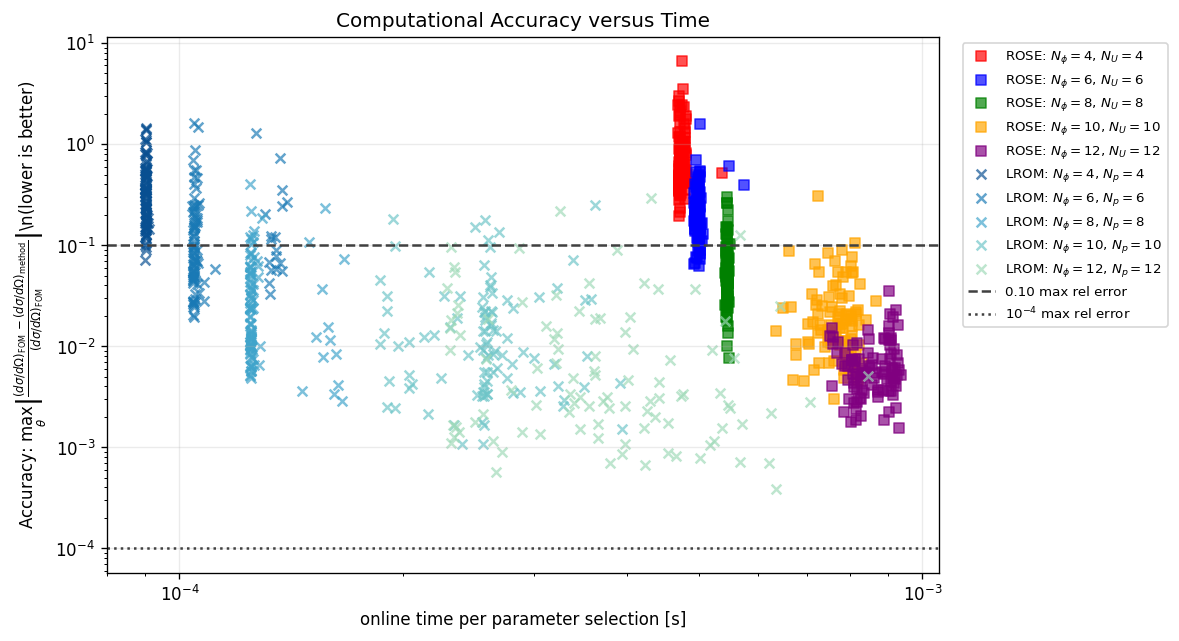

In [11]:
fig, ax = plt.subplots(figsize=(12.5, 5.8))
ROSE_CAT_COLORS = dict(
    zip(CAT_CONFIGURATIONS, ("red", "blue", "green", "orange", "purple"))
)
LROM_CAT_COLORS = dict(
    zip(CAT_CONFIGURATIONS, plt.cm.GnBu(np.linspace(0.95, 0.40, 5)))
)
CAT_ALPHA = 0.68
CAT_ACCURACY_LABEL = (
    r"Accuracy: $\max_\theta\left|"
    r"\frac{(d\sigma/d\Omega)_{\mathrm{FOM}}-(d\sigma/d\Omega)_{\mathrm{method}}}"
    r"{(d\sigma/d\Omega)_{\mathrm{FOM}}}\right|$\n(lower is better)"
)

for n_phi, n_u in CAT_CONFIGURATIONS:
    result = rose_results[(n_phi, n_u)]
    ax.scatter(
        result["test_seconds"], result["test_maximum_over_angle_error"],
        marker="s", s=30, alpha=CAT_ALPHA, color=ROSE_CAT_COLORS[(n_phi, n_u)],
        label=rf"ROSE: $N_\phi={n_phi}$, $N_U={n_u}$",
    )

for n_phi, n_p in CAT_CONFIGURATIONS:
    result = lrom_results[(n_phi, n_p)]
    ax.scatter(
        result["test_seconds"], result["test_maximum_over_angle_error"],
        marker="x", s=34, alpha=CAT_ALPHA, color=LROM_CAT_COLORS[(n_phi, n_p)],
        label=rf"LROM: $N_\phi={n_phi}$, $N_p={n_p}$",
    )

ax.axhline(0.10, color="0.25", linestyle="--", label="0.10 max rel error")
ax.axhline(1e-4, color="0.25", linestyle=":", label=r"$10^{-4}$ max rel error")
ax.set_xscale("log")
ax.set_yscale("log", nonpositive="clip")
ax.xaxis.set_major_formatter(LOG_FORMATTER)
ax.yaxis.set_major_formatter(LOG_FORMATTER)
ax.set_xlabel("online time per parameter selection [s]")
ax.set_ylabel(CAT_ACCURACY_LABEL)
ax.set_title("Computational Accuracy versus Time")

ax.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left", fontsize=8)
fig.subplots_adjust(right=0.68)
plt.show()